<a href="https://colab.research.google.com/github/Nemosimes/NLP-Project/blob/MS1/MS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_file_path = '/content/project data.zip'
extraction_path = '.' # Extract into the current directory

# Create the extraction directory if it doesn't exist (not strictly needed for '.', but good practice for other paths)
os.makedirs(extraction_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"'{zip_file_path}' extracted to '{extraction_path}'")


'/content/project data.zip' extracted to '.'


In [ ]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
TRANSCRIPT_PATH = "/content/Project Data/Transcripts"
QA_PATH = "/content/Project Data/QA"
print("Transcripts:", os.listdir(TRANSCRIPT_PATH))
print("QA files:", os.listdir(QA_PATH))

Transcripts: ['منابع النيل  الدحيح.txt', 'هل Citizen Kane أفضل فيلم في التاريخ؟  الدحيح.txt', 'أعظم طائرة حربية  الدحيح.txt', 'الأخطبوط  الدحيح.txt', 'الساموراي  الدحيح.txt', 'تاج محل  الدحيح.txt', 'كيف تحولت روسيا إلى إمبراطورية؟  الدحيح.txt', 'جون كينيدي  الدحيح.txt', 'معركة ذي قار  الدحيح.txt', 'كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟  الدحيح.txt', 'فيزياء و فلسفة الحركة  الدحيح.txt', 'كيف تسيطر على عقول البشر؟  الدحيح.txt', 'مصير الأرض و الشمس و كل شيء  الدحيح.txt']
QA files: ['3AwL93uolIA_QA.csv', 'ArytJ_HZ-1E_QA.csv', 'yc7x5jNhXIQ_QA.csv', 'MOEwXtL2DQ4_QA.csv', 'DbuoaakWh7g_QA.csv', '8ZL2AAxQmLQ_QA.csv', 'z2NGnjXG5uQ_QA.csv', 'IxsJEffQAZA_QA.csv', 'gv5hDK2YQfA_QA.csv', 'NJ-JcDcff8o_QA.csv', '8rcY34IA-6I_QA.csv', '0urc3PabvOs_QA.csv', 'nc8oJTETqoI_QA.csv']


In [ ]:
transcripts = {}

for file in os.listdir(TRANSCRIPT_PATH):

    video_id = file.replace(".txt", "")

    with open(os.path.join(TRANSCRIPT_PATH, file), "r", encoding="utf-8") as f:
        transcripts[video_id] = f.read()

print("Loaded transcripts:", len(transcripts))
#print(transcripts)

Loaded transcripts: 13


In [ ]:
qa_data = []

for file in os.listdir(QA_PATH):

    df = pd.read_csv(os.path.join(QA_PATH, file))
    qa_data.append(df)

qa_df = pd.concat(qa_data, ignore_index=True)

print("Total QA pairs:", len(qa_df))
qa_df.head(20)

Total QA pairs: 3890


,video_id,video_title,question_id,question,answer,difficulty
0,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q001,ماذا ورد في النص حول هذه الجزئية؟,والساموزين والسامو عليكم!,Easy
1,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q002,ما الجملة المذكورة في هذا الموضع؟,من كل مَن حرمه من حلم الساموراي...,Medium
2,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q003,كيف صيغت العبارة في النص؟,السلام عليكم ورحمة الله وبركاته،,Easy
3,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q004,ما الذي قيل في هذا السياق؟,"من برنامج ""الدحّيح""!",Medium
4,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q005,ما النص الحرفي المذكور هنا؟,خلّيني آخدك مش لمكان واحد،,Easy
5,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q006,ماذا ورد في النص حول هذه الجزئية؟,تعود إلى عائلات ساموراي كبيرة،,Medium
6,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q007,ما الجملة المذكورة في هذا الموضع؟,منتظرين حُكم الإعدام،,Easy
7,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q008,كيف صيغت العبارة في النص؟,من حَد بيحصلّه هذا الحُكم,Medium
8,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q009,ما الذي قيل في هذا السياق؟,بل كان بيخططلها.,Easy
9,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q010,ما النص الحرفي المذكور هنا؟,عشان تستقبل هذا الحدث،,Medium


In [ ]:
qa_df.to_csv("qa_english.csv", index=False, encoding='utf-8-sig')

## Dataset Structure

The dataset consists of two folders:

1. Transcript/
   Contains 13 Arabic transcripts corresponding to ElDa7ee7 Season 8 videos.

2. QA/
   Contains 13 CSV files with 300 extractive question-answer pairs per video.

Each QA pair contains:
- video_id
- video_title
- question
- answer
- difficulty

In [36]:
print("Number of transcripts:", len(transcripts))
print("Total QA pairs:", len(qa_df))
print("Average transcript length:",
      sum(len(t.split()) for t in transcripts.values()) / len(transcripts))

Number of transcripts: 13
Total QA pairs: 3890
Average transcript length: 6875.2307692307695


In [ ]:
#from google.colab import files
#files.download("qa_english.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Attach Transcript Context

In [ ]:
def clean_title_for_lookup(title):
    # Remove the YouTube video ID and ' | الدحيح' part from the title
    # The transcripts keys look like 'فيزياء و فلسفة الحركة  الدحيح'
    # The qa_df['video_title'] looks like 'كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟ | الدحيح'
    # Correcting the space: ` | الدحيح` should be replaced with `  الدحيح` (two spaces)
    cleaned_title = title.replace(' | الدحيح', '  الدحيح')
    return cleaned_title

# Apply the cleaning function to create a new column for lookup
qa_df['cleaned_video_title'] = qa_df['video_title'].apply(clean_title_for_lookup)

def get_context(cleaned_video_title):
    return transcripts.get(cleaned_video_title, "")

qa_df["context"] = qa_df["cleaned_video_title"].apply(get_context)
qa_df.head()

,video_id,video_title,question_id,question,answer,difficulty,cleaned_video_title,context
0,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q001,ماذا ورد في النص حول هذه الجزئية؟,والساموزين والسامو عليكم!,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...
1,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q002,ما الجملة المذكورة في هذا الموضع؟,من كل مَن حرمه من حلم الساموراي...,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...
2,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q003,كيف صيغت العبارة في النص؟,السلام عليكم ورحمة الله وبركاته،,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...
3,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q004,ما الذي قيل في هذا السياق؟,"من برنامج ""الدحّيح""!",Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...
4,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q005,ما النص الحرفي المذكور هنا؟,خلّيني آخدك مش لمكان واحد،,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...


Basic Dataset EDA

In [ ]:
qa_df["question_len"] = qa_df["question"].apply(lambda x: len(str(x).split()))
qa_df["answer_len"] = qa_df["answer"].apply(lambda x: len(str(x).split()))
qa_df[["question_len","answer_len"]].describe()

,question_len,answer_len
count,3890.000000,3890.000000
mean,6.084833,4.940617
std,1.372132,1.617219
min,3.000000,1.000000
25%,5.000000,4.000000
50%,6.000000,5.000000
75%,7.000000,6.000000
max,9.000000,10.000000


Difficulty Distribution

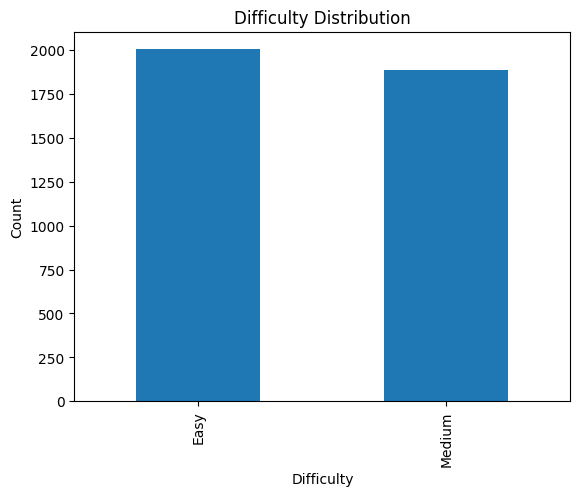

In [ ]:
qa_df["difficulty"].value_counts().plot(kind="bar")

plt.title("Difficulty Distribution")
plt.xlabel("Difficulty")
plt.ylabel("Count")
plt.show()

Transcript Length Analysis

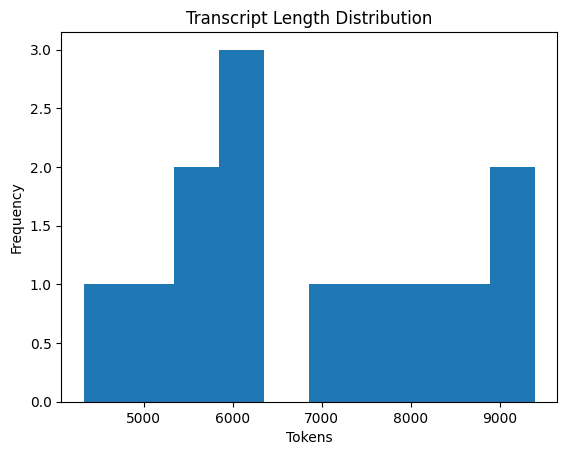

In [ ]:
transcript_lengths = [len(text.split()) for text in transcripts.values()]

plt.hist(transcript_lengths)
plt.title("Transcript Length Distribution")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.show()

In [40]:
transcript_word_counts = [len(t.split()) for t in transcripts.values()]

print("Average transcript length:", sum(transcript_word_counts)/len(transcript_word_counts))
print("Max transcript length:", max(transcript_word_counts))
print("Min transcript length:", min(transcript_word_counts))

Average transcript length: 6875.2307692307695
Max transcript length: 9393
Min transcript length: 4329


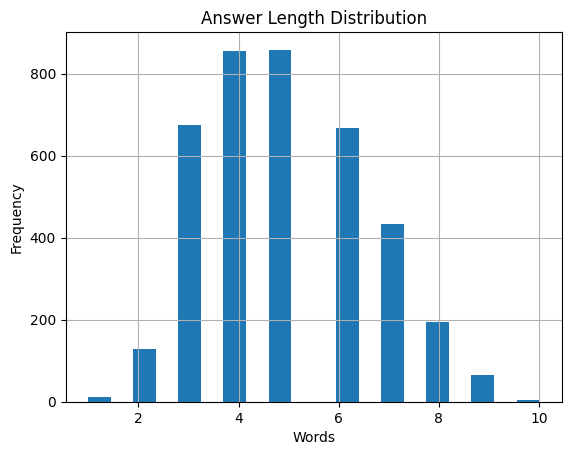

In [37]:
qa_df["answer_len"] = qa_df["answer"].apply(lambda x: len(str(x).split()))

qa_df["answer_len"].hist(bins=20)
plt.title("Answer Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

Detect Code Switching (Arabic + English) in questions

In [ ]:
def contains_english(text):
    return bool(re.search(r'[a-zA-Z]', str(text)))

qa_df["english_in_question"] = qa_df["question"].apply(contains_english)
qa_df.head()

,video_id,video_title,question_id,question,answer,difficulty,cleaned_video_title,context,question_len,answer_len,english_in_question
0,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q001,ماذا ورد في النص حول هذه الجزئية؟,والساموزين والسامو عليكم!,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,7,3,False
1,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q002,ما الجملة المذكورة في هذا الموضع؟,من كل مَن حرمه من حلم الساموراي...,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,7,False
2,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q003,كيف صيغت العبارة في النص؟,السلام عليكم ورحمة الله وبركاته،,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,5,5,False
3,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q004,ما الذي قيل في هذا السياق؟,"من برنامج ""الدحّيح""!",Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,3,False
4,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q005,ما النص الحرفي المذكور هنا؟,خلّيني آخدك مش لمكان واحد،,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,5,5,False


In [ ]:
qa_df["english_in_question"].value_counts()

,count
english_in_question,
False,3890


 Timestamps

In [ ]:
timestamp_pattern = r'\d+\.\d+:'

for vid, text in transcripts.items():

    matches = re.findall(timestamp_pattern, text)

    if matches:
        print(vid, "timestamps:", len(matches))

منابع النيل  الدحيح timestamps: 1065
هل Citizen Kane أفضل فيلم في التاريخ؟  الدحيح timestamps: 717
أعظم طائرة حربية  الدحيح timestamps: 761
الأخطبوط  الدحيح timestamps: 784
الساموراي  الدحيح timestamps: 662
تاج محل  الدحيح timestamps: 547
كيف تحولت روسيا إلى إمبراطورية؟  الدحيح timestamps: 1166
جون كينيدي  الدحيح timestamps: 1125
معركة ذي قار  الدحيح timestamps: 1006
كيف تنقل جبل وزنه 30 طن قبل أن يغرق؟  الدحيح timestamps: 757
فيزياء و فلسفة الحركة  الدحيح timestamps: 955
كيف تسيطر على عقول البشر؟  الدحيح timestamps: 908
مصير الأرض و الشمس و كل شيء  الدحيح timestamps: 656


In [38]:
for vid, text in list(transcripts.items())[:1]:
    print(text[:500])

0.16: دي كل الاحداثيات اللي معانا وملخص للبعثه
3.919: اكتشفته قبل ما تيجي لا لا البعثه
7.22: [موسيقى] الاستكشافيه اللي قدامي دي بايظه
9.2: خالص المؤن مضروبه والاتجاهات بايظه انا
12.88: عايز اعرف مين المستكشف الحمار اللي كان
14.839: شغال قبلي
15.719: >> الجنرال ارثر الله يرحمه قبل ما التمساح
19.6: يعمله بوفتيك
20.92: >> مبدئيا البوصله دي كارفه شمال شرق ممكن
23.8: اجيب لكم حاجه من عندي باستعمال خفيف بس
27.279: هتكلفكم
28.199: >> ماشي هات ونحاسبك
32.559: والخريطه دي هندي فرز تاني حتى طعمها
35.16: ت


Transcripts contain timestamp artifacts and informal punctuation
because they are web-scraped from YouTube captions. These artifacts
can introduce noise into the vocabulary and negatively affect model
training if not removed.

In [41]:
def remove_timestamps(text):
    timestamp_pattern = r'\d+\.\d+:'
    return re.sub(timestamp_pattern, '', text)

#qa_df["context_clean"] = qa_df["context"].apply(remove_timestamps)
#qa_df.head()

In [42]:
print("Raw transcript sample:\n")
print(list(transcripts.values())[0][:500])

Raw transcript sample:

0.16: دي كل الاحداثيات اللي معانا وملخص للبعثه
3.919: اكتشفته قبل ما تيجي لا لا البعثه
7.22: [موسيقى] الاستكشافيه اللي قدامي دي بايظه
9.2: خالص المؤن مضروبه والاتجاهات بايظه انا
12.88: عايز اعرف مين المستكشف الحمار اللي كان
14.839: شغال قبلي
15.719: >> الجنرال ارثر الله يرحمه قبل ما التمساح
19.6: يعمله بوفتيك
20.92: >> مبدئيا البوصله دي كارفه شمال شرق ممكن
23.8: اجيب لكم حاجه من عندي باستعمال خفيف بس
27.279: هتكلفكم
28.199: >> ماشي هات ونحاسبك
32.559: والخريطه دي هندي فرز تاني حتى طعمها
35.16: ت


In [43]:
print("Cleaned transcript sample:\n")
print(remove_timestamps(list(transcripts.values())[0])[:500])

Cleaned transcript sample:

 دي كل الاحداثيات اللي معانا وملخص للبعثه
 اكتشفته قبل ما تيجي لا لا البعثه
 [موسيقى] الاستكشافيه اللي قدامي دي بايظه
 خالص المؤن مضروبه والاتجاهات بايظه انا
 عايز اعرف مين المستكشف الحمار اللي كان
 شغال قبلي
 >> الجنرال ارثر الله يرحمه قبل ما التمساح
 يعمله بوفتيك
 >> مبدئيا البوصله دي كارفه شمال شرق ممكن
 اجيب لكم حاجه من عندي باستعمال خفيف بس
 هتكلفكم
 >> ماشي هات ونحاسبك
 والخريطه دي هندي فرز تاني حتى طعمها
 تشيكن تيك مسله انا ما بشتغلش غير بخرايط
 فرنساوي فرز اول مؤاخذه عندكم يا سيدي ما
 عن


Dialect vs MSA indicators

In [ ]:
df=qa_df.copy()

In [ ]:
egyptian_words = ["ليه",
"انتو",
"بتاع",
    "إيه", "دا", "دي", "دول", "بقى", "مش", "كدا", "كده",
    "احنا", "عشان", "لما", "دلوقتي", "فيه", "عايز",
    "خالص", "يعني", "ياه", "بقا", "ولا", "هيبقى", "هتبقى",
    "بيعمل", "بيقول", "بيشوف", "هيجي", "هيعمل", "ممكن",
"حاجة", "زي", "كمان", "برضه", "بس", "طب", "يا ابني",
]
def count_dialect(text):

    count = 0

    for word in egyptian_words:
        count += text.split().count(word)

    return count

df["dialect_count"] = df["context"].apply(count_dialect)

print("Total dialect occurrences:",
      df["dialect_count"].sum())

Total dialect occurrences: 1198360


Narrative Markers (Storytelling Language)

In [ ]:
narrative_markers = [
"تخيل",
"طيب",
"خلينا",
"بص",
"فكر",
"تعالى",
"دلوقتي"
]

In [ ]:
def count_narrative(text):

    count = 0

    for word in narrative_markers:
        count += text.split().count(word)

    return count

df["narrative_count"] = df["context"].apply(count_narrative)

print("Total narrative markers:",
      df["narrative_count"].sum())

Total narrative markers: 20390


Named Entity Frequency

In [ ]:
entities = [
"اينشتاين",
"نيوتن",
"داروين",
"تورنج",
"اديسون",
"ارسطو",
"افلاطون"
]
entity_counts = {}

for entity in entities:

    count = df["context"].str.contains(entity).sum()

    entity_counts[entity] = count

print(entity_counts)

{'اينشتاين': np.int64(0), 'نيوتن': np.int64(300), 'داروين': np.int64(300), 'تورنج': np.int64(0), 'اديسون': np.int64(0), 'ارسطو': np.int64(0), 'افلاطون': np.int64(0)}


Vocabulary Size

In [ ]:
all_words = []

for text in df["context"]:

    all_words.extend(str(text).split())

vocab = Counter(all_words)

print("Vocabulary size:", len(vocab))

Vocabulary size: 36776


In [ ]:
print(vocab.most_common(20))

[('في', 597280), ('يا', 540460), ('عزيزي،', 392960), ('من', 386780), ('اللي', 382160), ('ما', 339650), ('إن', 273980), ('على', 264820), ('كان', 185530), ('دا', 141180), ('مش', 140320), ('هو', 128260), ('كل', 123590), ('عشان', 109190), ('زي', 101910), ('دي', 101240), ('انت', 88490), ('بس', 78620), ('كانت', 78180), ('كدا،', 74660)]


Question Word Analysis

In [ ]:
question_starts = []

for q in df["question"]:

    first_word = str(q).split()[0]

    question_starts.append(first_word)

Counter(question_starts).most_common(10)

[('ما', 2390),
 ('ماذا', 690),
 ('كيف', 660),
 ('في', 60),
 ('لماذا', 30),
 ('كم', 30),
 ('أين', 30)]

N-gram Analysis (Common Word Patterns)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2,2),  # bigrams
    token_pattern=r"(?u)\b\w+\b"
)

X = vectorizer.fit_transform(df["context"])

sum_words = X.sum(axis=0)

bigrams = [(word, sum_words[0, idx])
           for word, idx in vectorizer.vocabulary_.items()]

bigrams = sorted(bigrams, key=lambda x: x[1], reverse=True)

print("Top 20 bigrams:")
print(bigrams[:20])

Top 20 bigrams:
[('يا عزيزي', np.int64(413650)), ('أبو حميد', np.int64(54640)), ('لم ا', np.int64(51340)), ('جد ا', np.int64(48790)), ('يا أبو', np.int64(42660)), ('زي ما', np.int64(38880)), ('إن هو', np.int64(35890)), ('مثل ا', np.int64(30450)), ('ق د', np.int64(30240)), ('دا يا', np.int64(28370)), ('عزيزي إن', np.int64(27830)), ('ه ما', np.int64(24000)), ('د ول', np.int64(21260)), ('ما فيش', np.int64(20050)), ('هو اللي', np.int64(18250)), ('إن انت', np.int64(17950)), ('من غير', np.int64(17900)), ('اللي كان', np.int64(17700)), ('إن ه', np.int64(17400)), ('خل يني', np.int64(17330))]


Checking answers of each transcript

In [ ]:
import pandas as pd

multi_answers = (
    df.groupby(["video_id", "question"])["answer"]
    .nunique()
    .reset_index()
)

problem_cases = multi_answers[multi_answers["answer"] > 1]

print("Questions with multiple answers:", len(problem_cases))

Questions with multiple answers: 55


In [ ]:
examples = df.merge(problem_cases[["video_id","question"]],
                    on=["video_id","question"])

examples.head(10)

,video_id,video_title,question_id,question,answer,difficulty,cleaned_video_title,context,question_len,answer_len,english_in_question,context_clean,dialect_count,narrative_count
0,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q001,ماذا ورد في النص حول هذه الجزئية؟,والساموزين والسامو عليكم!,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,7,3,False,منذ زمنٍ بعيد،\n في أرضٍ ليست ببعيدة...\n كان...,208,1
1,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q002,ما الجملة المذكورة في هذا الموضع؟,من كل مَن حرمه من حلم الساموراي...,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,7,False,منذ زمنٍ بعيد،\n في أرضٍ ليست ببعيدة...\n كان...,208,1
2,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q003,كيف صيغت العبارة في النص؟,السلام عليكم ورحمة الله وبركاته،,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,5,5,False,منذ زمنٍ بعيد،\n في أرضٍ ليست ببعيدة...\n كان...,208,1
3,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q004,ما الذي قيل في هذا السياق؟,"من برنامج ""الدحّيح""!",Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,3,False,منذ زمنٍ بعيد،\n في أرضٍ ليست ببعيدة...\n كان...,208,1
4,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q005,ما النص الحرفي المذكور هنا؟,خلّيني آخدك مش لمكان واحد،,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,5,5,False,منذ زمنٍ بعيد،\n في أرضٍ ليست ببعيدة...\n كان...,208,1
5,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q006,ماذا ورد في النص حول هذه الجزئية؟,تعود إلى عائلات ساموراي كبيرة،,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,7,5,False,منذ زمنٍ بعيد،\n في أرضٍ ليست ببعيدة...\n كان...,208,1
6,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q007,ما الجملة المذكورة في هذا الموضع؟,منتظرين حُكم الإعدام،,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,3,False,منذ زمنٍ بعيد،\n في أرضٍ ليست ببعيدة...\n كان...,208,1
7,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q008,كيف صيغت العبارة في النص؟,من حَد بيحصلّه هذا الحُكم,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,5,5,False,منذ زمنٍ بعيد،\n في أرضٍ ليست ببعيدة...\n كان...,208,1
8,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q009,ما الذي قيل في هذا السياق؟,بل كان بيخططلها.,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,3,False,منذ زمنٍ بعيد،\n في أرضٍ ليست ببعيدة...\n كان...,208,1
9,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q010,ما النص الحرفي المذكور هنا؟,عشان تستقبل هذا الحدث،,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,5,4,False,منذ زمنٍ بعيد،\n في أرضٍ ليست ببعيدة...\n كان...,208,1


In [ ]:
merged_df = df.merge(problem_cases[['video_id', 'question']], on=['video_id', 'question'], how='inner')

# Sort by video_id and question to group similar questions together
merged_df = merged_df.sort_values(by=['video_id', 'question']).reset_index(drop=True)

# Display only the relevant columns for easier inspection
display(merged_df[['video_title', 'question', 'answer']])

,video_title,question,answer
0,مصير الأرض و الشمس و كل شيء | الدحيح,كيف صيغت العبارة هنا؟,- أيوة.
1,مصير الأرض و الشمس و كل شيء | الدحيح,كيف صيغت العبارة هنا؟,- عشان كانوا فاضيين وفي (اليونان) و...
2,مصير الأرض و الشمس و كل شيء | الدحيح,كيف صيغت العبارة هنا؟,السلام عليكم ورحمة الله وبركاته،
3,مصير الأرض و الشمس و كل شيء | الدحيح,كيف صيغت العبارة هنا؟,"""إقليدس""، ""هيراقليطس""."
4,مصير الأرض و الشمس و كل شيء | الدحيح,كيف صيغت العبارة هنا؟,هو عالَم مثالي غير محسوس،
...,...,...,...
3295,كيف تحولت روسيا إلى إمبراطورية؟ | الدحيح,ماذا ورد في هذا الموضع من النص؟,مجرد عيّل عنده 15 سنة وخلاص،
3296,كيف تحولت روسيا إلى إمبراطورية؟ | الدحيح,ماذا ورد في هذا الموضع من النص؟,شوف لمّا يبقى عنده 15، ممكن يعمل إيه!
3297,كيف تحولت روسيا إلى إمبراطورية؟ | الدحيح,ماذا ورد في هذا الموضع من النص؟,كانت آه قليلة،
3298,كيف تحولت روسيا إلى إمبراطورية؟ | الدحيح,ماذا ورد في هذا الموضع من النص؟,وفيه جنود غرقوا في النهر وهُما بيعدّوا،


# **Text Normalisation**


1.   Remove diacritics (تشكيل)
2.   Normalise letter variants
1.   Remove التطويل
1.   Remove punctations and non-arabic letters


In [ ]:
import re

def normalize_arabic(text):
    # Remove diacritics
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    # Remove Tatweel
    text = re.sub(r'ـ', '', text)
    # Normalize letters
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    # Optional: remove non-Arabic letters
    text = re.sub(r'[^\u0621-\u064A\s]', '', text)
    return text

# Apply to your dataframe
df['answer'] = df['answer'].astype(str).apply(normalize_arabic)
df['context_clean'] = df['context_clean'].astype(str).apply(normalize_arabic)

df.head(10)

,video_id,video_title,question_id,question,answer,difficulty,cleaned_video_title,context,question_len,answer_len,english_in_question,context_clean,dialect_count,narrative_count
0,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q001,ماذا ورد في النص حول هذه الجزئية؟,والساموزين والسامو عليكم,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,7,3,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1
1,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q002,ما الجملة المذكورة في هذا الموضع؟,من كل من حرمه من حلم الساموراي,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,7,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1
2,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q003,كيف صيغت العبارة في النص؟,السلام عليكم ورحمه الله وبركاته,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,5,5,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1
3,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q004,ما الذي قيل في هذا السياق؟,من برنامج الدحيح,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,3,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1
4,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q005,ما النص الحرفي المذكور هنا؟,خليني اخدك مش لمكان واحد,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,5,5,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1
5,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q006,ماذا ورد في النص حول هذه الجزئية؟,تعود الي عايلات ساموراي كبيره,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,7,5,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1
6,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q007,ما الجملة المذكورة في هذا الموضع؟,منتظرين حكم الاعدام,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,3,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1
7,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q008,كيف صيغت العبارة في النص؟,من حد بيحصله هذا الحكم,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,5,5,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1
8,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q009,ما الذي قيل في هذا السياق؟,بل كان بيخططلها,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,3,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1
9,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q010,ما النص الحرفي المذكور هنا؟,عشان تستقبل هذا الحدث,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,5,4,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1


In [ ]:

df["dialect_clean_count"]=df["context_clean"].apply(count_dialect)

print("Total dialect occurrences:",
      df["dialect_count"].sum())

print("Total dialect occurrences after normalization:",
      df["dialect_clean_count"].sum())

Total dialect occurrences: 1198360
Total dialect occurrences after normalization: 1507880


In [44]:
sample = qa_df["context"].iloc[0]

print("Before normalization:")
print(sample[:200])

print("\nAfter normalization:")
print(normalize_arabic(sample)[:200])

Before normalization:
0.167: منذ زمنٍ بعيد،
2.6: في أرضٍ ليست ببعيدة...
6.818: كان هُناك طفلٌ مصريٌ سمين،
10.204: يحلم بأن يكون أول ساموراي مصري في العالم.
17.745: كَبُر الطفل،
19.384: وسافر لـ"اليابان"،
21.312: رفضه كل مُ

After normalization:
 منذ زمن بعيد
 في ارض ليست ببعيده
 كان هناك طفل مصري سمين
 يحلم بان يكون اول ساموراي مصري في العالم
 كبر الطفل
 وسافر لاليابان
 رفضه كل معلمي الساموراي
والساموزين والسامو عليكم
 السلام عليكم
 تاجج الغ


# **Data preparation**

# Tokenisation

In [ ]:
df["answer_tokens"] = df["answer"].apply(lambda x: x.split())
df["context_tokens"] = df["context_clean"].apply(lambda x: x.split())

df.head(2)

,video_id,video_title,question_id,question,answer,difficulty,cleaned_video_title,context,question_len,answer_len,english_in_question,context_clean,dialect_count,narrative_count,dialect_clean_count,answer_tokens,context_tokens
0,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q001,ماذا ورد في النص حول هذه الجزئية؟,والساموزين والسامو عليكم,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,7,3,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1,287,"[والساموزين, والسامو, عليكم]","[منذ, زمن, بعيد, في, ارض, ليست, ببعيده, كان, ه..."
1,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q002,ما الجملة المذكورة في هذا الموضع؟,من كل من حرمه من حلم الساموراي,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,7,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1,287,"[من, كل, من, حرمه, من, حلم, الساموراي]","[منذ, زمن, بعيد, في, ارض, ليست, ببعيده, كان, ه..."


Build vocabulary

In [ ]:
from collections import Counter

# Collect all words from both columns
all_words = []

for col in ["answer", "context_clean"]:
    for text in df[col]:
        all_words.extend(str(text).split())  # make sure text is string

# Count frequency
word_counts = Counter(all_words)

# Build vocab: word -> id
vocab = {w: i+1 for i, (w, _) in enumerate(word_counts.most_common())}

print("Vocab size:", len(vocab))

Vocab size: 18320


In [46]:
UNK_TOKEN = "<UNK>"

vocab = {word:i+1 for i,(word,_) in enumerate(word_counts.items())}
vocab[UNK_TOKEN] = len(vocab)+1

Convert text to number for model

In [48]:
def to_ids(text):
    return [vocab.get(w, vocab[UNK_TOKEN]) for w in text.split()]

# Convert both columns to ids
df["context_ids"] = df["context_clean"].apply(to_ids)
df["answer_ids"] = df["answer"].apply(to_ids)

# See the first 2 rows
df.head(2)

,video_id,video_title,question_id,question,answer,difficulty,cleaned_video_title,context,question_len,answer_len,english_in_question,context_clean,dialect_count,narrative_count,dialect_clean_count,answer_tokens,context_tokens,context_ids,answer_ids
0,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q001,ماذا ورد في النص حول هذه الجزئية؟,والساموزين والسامو عليكم,Easy,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,7,3,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1,287,"[والساموزين, والسامو, عليكم]","[منذ, زمن, بعيد, في, ارض, ليست, ببعيده, كان, ه...","[6726, 2595, 1428, 87, 2798, 2663, 6727, 33, 1...","[1, 2, 3]"
1,3AwL93uolIA,الساموراي | الدحيح,3AwL93uolIA_Q002,ما الجملة المذكورة في هذا الموضع؟,من كل من حرمه من حلم الساموراي,Medium,الساموراي الدحيح,0.167: منذ زمنٍ بعيد،\n2.6: في أرضٍ ليست ببعيد...,6,7,False,منذ زمن بعيد\n في ارض ليست ببعيده\n كان هناك ...,208,1,287,"[من, كل, من, حرمه, من, حلم, الساموراي]","[منذ, زمن, بعيد, في, ارض, ليست, ببعيده, كان, ه...","[6726, 2595, 1428, 87, 2798, 2663, 6727, 33, 1...","[4, 5, 4, 6, 4, 7, 8]"


Padding

In [49]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# context sequences
context_max_len = 7500  # maybe 95th percentile of context lengths
context_padded = pad_sequences(
    df["context_ids"], maxlen=context_max_len, padding="post"
)

# answer sequences
answer_max_len = 10  # maybe 95th percentile of answer lengths
answer_padded = pad_sequences(
    df["answer_ids"], maxlen=answer_max_len, padding="post"
)

print("Context shape:", context_padded.shape)
print("Answer shape:", answer_padded.shape)


Context shape: (3890, 7500)
Answer shape: (3890, 10)


## Limitations and Future Work

Several challenges remain in the dataset:

* Long transcript contexts may exceed transformer limits.
* Egyptian dialect expressions may affect tokenization.
* Some questions may correspond to multiple valid answer spans.
* Code-switching (Arabic-English) introduces multilingual vocabulary.

These issues will be addressed in MS2 and MS3 through
context chunking, transformer-based models, and retrieval-based
methods.